In [ ]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot
import matplotlib.pyplot as plt


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Leer datos
data = pd.read_csv('/content/drive/MyDrive/train.csv', delimiter=',')

data.head()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


In [ ]:
X = data.drop('critical_temp', axis=1)
y = data['critical_temp']

In [ ]:
X = X.values
y = y.values


In [ ]:
m = y.size
print("Número de ejemplos:", m)

Número de ejemplos: 21263


In [ ]:
print(X.shape)
print(y.shape)

(21263, 81)
(21263,)


In [ ]:
def featureNormalize(X):

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [ ]:
X, mu, sigma = featureNormalize(X)

In [ ]:
m = len(y)

In [ ]:
X = np.concatenate([np.ones((m,1)), X], axis=1)

In [ ]:
def computeCostMulti(X, y, theta):

    m = len(y)

    predictions = X.dot(theta)
    errors = predictions - y

    J = (1/(2*m)) * np.sum(errors**2)

    return J

In [ ]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    m = len(y)
    J_history = []

    for i in range(num_iters):

        predictions = X.dot(theta)
        errors = predictions - y

        theta = theta - (alpha/m) * (X.T.dot(errors))

        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

In [ ]:
theta = np.zeros(X.shape[1])

In [ ]:
alpha = 0.01
num_iters = 10000

theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

print("Parámetros aprendidos:")
print(theta)

Parámetros aprendidos:
[ 3.44212191e+01 -2.42155138e+00  4.29668524e+00 -2.18684636e+00
  1.29819432e+00 -1.27658560e+00 -6.66747101e+00  4.32297901e+00
  9.88076253e+00 -1.03380804e+00 -7.10440111e-01 -5.43492275e+00
  3.22390585e-01  5.63248319e-01  1.35453749e+00  4.05284084e-01
  1.84749890e+00  2.20961335e+00  9.38162319e+00  2.97813321e+00
 -6.94104737e+00 -3.66443915e+00  1.13079318e+00  9.48313238e+00
 -5.55437417e+00 -1.19064603e+00  6.12435070e-01  7.06856530e+00
  1.09119846e+01 -4.11516277e+00 -9.11520592e+00  6.96580034e+00
 -4.16073920e+00 -6.78981109e-01 -1.54169441e+00  3.44034201e+00
  2.40797114e+00 -6.66949562e+00 -2.65569498e+00  1.45304327e+00
  2.60775663e+00 -2.28885989e+00  2.83635471e+00  6.58952082e+00
 -1.04262136e-01 -8.35763154e+00 -1.59544305e+00 -6.72540528e+00
 -1.18774825e+01 -4.90667650e+00  1.32406746e+01 -4.73904513e+00
  1.90357021e+00 -3.96179735e-01 -2.08176693e+00 -2.58112767e-02
 -1.21394190e+00  7.48529310e+00 -4.44402369e+00  3.13564212e+00
  

In [ ]:
print(J_history[:20])

[np.float64(1022.9289058057933), np.float64(939.6157645645757), np.float64(891.0398664582971), np.float64(859.2810135645294), np.float64(835.880363132139), np.float64(816.8222576617395), np.float64(800.1807500542423), np.float64(785.0153856784093), np.float64(770.852727983533), np.float64(757.4425826015304), np.float64(744.6430977247443), np.float64(732.3663696934406), np.float64(720.5524905011334), np.float64(709.1569953786176), np.float64(698.1446492828779), np.float64(687.4862536319565), np.float64(677.1569102676715), np.float64(667.1350037165141), np.float64(657.4015500681627), np.float64(647.9397431243636)]


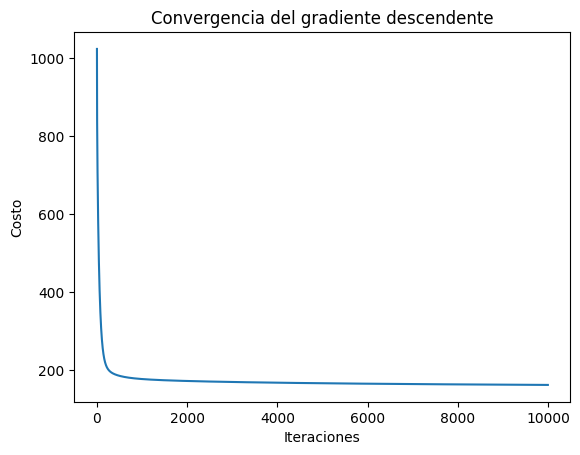

In [ ]:
plt.plot(J_history)
plt.xlabel("Iteraciones")
plt.ylabel("Costo")
plt.title("Convergencia del gradiente descendente")
plt.show()

In [ ]:
X_original = data.drop('critical_temp', axis=1).values

In [ ]:
nuevo_material = X_original[10000]

In [ ]:
nuevo_material = (nuevo_material - mu) / sigma

In [ ]:
nuevo_material = np.insert(nuevo_material,0,1)

In [ ]:
prediccion = nuevo_material.dot(theta)

print("Predicción:", prediccion)
print("Valor real:", y[0])

Predicción: 39.169735327182536
Valor real: 29.0


In [ ]:
valor_real = y[0]

print("Predicción:", prediccion)
print("Valor real:", valor_real)

Predicción: 39.169735327182536
Valor real: 29.0


In [ ]:
print("Costo inicial:", J_history[0])
print("Costo final:", J_history[-1])

Costo inicial: 1022.9289058057933
Costo final: 162.6075362809386


In [ ]:
predicciones = X.dot(theta)

mse = np.mean((predicciones - y)**2)
rmse = np.sqrt(mse)

print("Error cuadrático medio:", mse)
print("RMSE:", rmse)

Error cuadrático medio: 325.21507256187726
RMSE: 18.033720430401413


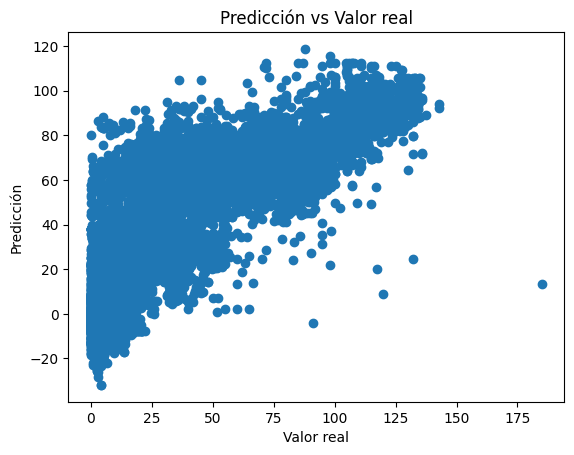

In [ ]:
plt.scatter(y, predicciones)
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("Predicción vs Valor real")
plt.show()